In [4]:
import time as CPUTime
from itertools import product
import time

In [5]:
import math
import numpy as np
from IPython.display import clear_output
from tqdm import tqdm_notebook as tqdm

import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.color_palette("bright")
import matplotlib as mpl
import matplotlib.cm as cm

import torch
from torch import Tensor
from torch import nn
from torch.nn  import functional as F 
from torch.autograd import Variable

use_cuda = torch.cuda.is_available()

In [6]:
def ode_solve(z0, t0, t1, f):
    """
    Simplest Euler ODE initial value solver
    """
    h_max = 0.01
    n_steps = math.ceil((abs(t1 - t0)/h_max).max().item())

    h = (t1 - t0)/n_steps
    t = t0
    z = z0

    for i_step in range(n_steps):
        z = z + h * f(z, t)
        t = t + h
    return z

In [7]:
class ODEF(nn.Module):
    def forward_with_grad(self, z, t, grad_outputs):
        """Compute f and a df/dz, a df/dp, a df/dt"""
        batch_size = z.shape[0]

        out = self.forward(z, t)

        a = grad_outputs#######  no .squeeze()
        adfdz, adfdt, *adfdp = torch.autograd.grad(
            (out,), (z, t) + tuple(self.parameters()), grad_outputs=(a),
            allow_unused=True, retain_graph=True
        )#allow_unused=True
        ######### ingore none
        # none_count = sum(1 for p_grad in adfdp if p_grad is None)
        # print(f"Number of None gradients in adfdp: {none_count}")
        
        adfdp = [p_grad if p_grad is not None else torch.zeros_like(p) 
                 for p_grad, p in zip(adfdp, self.parameters())]
        
        ########



        
        # grad method automatically sums gradients for batch items, we have to expand them back 
        if adfdp is not None:
            adfdp = torch.cat([p_grad.flatten() for p_grad in adfdp]).unsqueeze(0)
            adfdp = adfdp.expand(batch_size, -1) / batch_size
        if adfdt is not None:
            adfdt = adfdt.expand(batch_size, 1) / batch_size
        return out, adfdz, adfdt, adfdp

    def flatten_parameters(self):
        p_shapes = []
        flat_parameters = []
        for p in self.parameters():
            p_shapes.append(p.size())
            flat_parameters.append(p.flatten())
        return torch.cat(flat_parameters)

In [8]:
class ODEAdjoint(torch.autograd.Function):
    @staticmethod
    def forward(ctx, z0, t, flat_parameters, func):
        assert isinstance(func, ODEF)
        bs, *z_shape = z0.size()
        time_len = t.size(0)

        with torch.no_grad():
            z = torch.zeros(time_len, bs, *z_shape).to(z0)
            z[0] = z0
            for i_t in range(time_len - 1):
                z0 = ode_solve(z0, t[i_t], t[i_t+1], func)
                z[i_t+1] = z0

        ctx.func = func
        ctx.save_for_backward(t, z.clone(), flat_parameters)
        return z

    @staticmethod
    def backward(ctx, dLdz):
        """
        dLdz shape: time_len, batch_size, *z_shape
        """
        func = ctx.func
        t, z, flat_parameters = ctx.saved_tensors
        time_len, bs, *z_shape = z.size()
        n_dim = np.prod(z_shape).astype(np.int32)
        

        n_params = flat_parameters.size(0)

        # Dynamics of augmented system to be calculated backwards in time
        def augmented_dynamics(aug_z_i, t_i):
            """
            tensors here are temporal slices
            t_i - is tensor with size: bs, 1
            aug_z_i - is tensor with size: bs, n_dim*2 + n_params + 1
            """
            z_i, a = aug_z_i[:, :n_dim], aug_z_i[:, n_dim:2*n_dim]  # ignore parameters and time

            # Unflatten z and a
            z_i = z_i.view(bs, *z_shape)
            a = a.view(bs, *z_shape)
            with torch.set_grad_enabled(True):
                t_i = t_i.detach().requires_grad_(True)
                z_i = z_i.detach().requires_grad_(True)
                func_eval, adfdz, adfdt, adfdp = func.forward_with_grad(z_i, t_i, grad_outputs=a)  
                adfdz = adfdz.to(z_i) if adfdz is not None else torch.zeros(bs, *z_shape).to(z_i)
                adfdp = adfdp.to(z_i) if adfdp is not None else torch.zeros(bs, n_params).to(z_i)
                adfdt = adfdt.to(z_i) if adfdt is not None else torch.zeros(bs, 1).to(z_i)

            # Flatten f and adfdz
            func_eval = func_eval.view(bs, n_dim)
            adfdz = adfdz.view(bs, n_dim) 
            return torch.cat((func_eval, -adfdz, -adfdp, -adfdt), dim=1)
     
        dLdz = dLdz.view(time_len, bs, n_dim)  # flatten dLdz for convenience
        with torch.no_grad():
            ## Create placeholders for output gradients
            # Prev computed backwards adjoints to be adjusted by direct gradients
            adj_z = torch.zeros(bs, n_dim).to(dLdz)
            adj_p = torch.zeros(bs, n_params).to(dLdz)
            # In contrast to z and p we need to return gradients for all times
            adj_t = torch.zeros(time_len, bs, 1).to(dLdz)

            for i_t in range(time_len-1, 0, -1):
                z_i = z[i_t]
                t_i = t[i_t]
                f_i = func(z_i, t_i).view(bs, n_dim)

                # Compute direct gradients
                dLdz_i = dLdz[i_t]
                dLdt_i = torch.bmm(torch.transpose(dLdz_i.unsqueeze(-1), 1, 2), f_i.unsqueeze(-1))[:, 0]

                # Adjusting adjoints with direct gradients
                adj_z += dLdz_i
                adj_t[i_t] = adj_t[i_t] - dLdt_i

                # Pack augmented variable
                aug_z = torch.cat((z_i.view(bs, n_dim), adj_z, torch.zeros(bs, n_params).to(z), adj_t[i_t]), dim=-1)

                # Solve augmented system backwards
                aug_ans = ode_solve(aug_z, t_i, t[i_t-1], augmented_dynamics)

                # Unpack solved backwards augmented system
                adj_z[:] = aug_ans[:, n_dim:2*n_dim]
                adj_p[:] += aug_ans[:, 2*n_dim:2*n_dim + n_params]
                adj_t[i_t-1] = aug_ans[:, 2*n_dim + n_params:]

                del aug_z, aug_ans

            ## Adjust 0 time adjoint with direct gradients
            # Compute direct gradients 
            dLdz_0 = dLdz[0]
            dLdt_0 = torch.bmm(torch.transpose(dLdz_0.unsqueeze(-1), 1, 2), f_i.unsqueeze(-1))[:, 0]

            # Adjust adjoints
            adj_z += dLdz_0
            adj_t[0] = adj_t[0] - dLdt_0
        return adj_z.view(bs, *z_shape), adj_t, adj_p, None

In [9]:
class NeuralODE(nn.Module):
    def __init__(self, func):
        super(NeuralODE, self).__init__()
        assert isinstance(func, ODEF)
        self.func = func

    def forward(self, z0, t=Tensor([0., 1.]), return_whole_sequence=False):
        t = t.to(z0)
        z = ODEAdjoint.apply(z0, t, self.func.flatten_parameters(), self.func)

        ########################   
        # z=normalize_trace_vector(z)
        if return_whole_sequence:
            return z
        else:
            return z[-1]

In [10]:
# class TimeEmbedding(nn.Module):
#     def __init__(self, embed_dim,time_dim=32):
#         super().__init__()
#         self.linear1 = nn.Linear(embed_dim+time_dim*2, embed_dim)
#         self.time_dim=time_dim
#         # self.linear2 = nn.Linear(embed_dim, embed_dim)

#     def forward(self,x , t):
#         time_dim=self.time_dim 
#         exp_values = torch.exp(torch.arange(time_dim,dtype=torch.float32) * (-torch.log(torch.tensor(100.0)) / time_dim))*10
#         # t = t.unsqueeze(1)  # (batch_size, 1)
#         embeddings = torch.cat([torch.sin(t * exp_values), torch.cos(t * exp_values)], dim=-1)        
#         t_tensor=embeddings.unsqueeze(0).expand(*x.shape[:-1],time_dim*2)
        
#         xt=torch.cat([x,t_tensor],dim=x.ndim-1)
#         # print(xt.shape)
#         output=self.linear1(xt)
#         return output
class Time_mult(nn.Module):
    def __init__(self, embed_dim,time_mul_dim=32):
        super().__init__()
        self.linear1 = nn.Linear(embed_dim, embed_dim)
        self.time_mul_dim=time_mul_dim
        # self.linear2 = nn.Linear(embed_dim, embed_dim)
    
    def forward(self,x , t):
        time_dim=self.time_mul_dim 
        exp_values = torch.exp(torch.arange(time_dim,dtype=torch.float32) * (-torch.log(torch.tensor(100.0)) / time_dim))*10
        # t = t.unsqueeze(1)  # (batch_size, 1)
        embeddings = torch.cat([torch.sin(t * exp_values), torch.cos(t * exp_values)], dim=-1)        
        t_tensor=embeddings.unsqueeze(0).expand(*x.shape[:-1],time_dim*2)
        x_=x.clone()
        x_[:,:time_dim*2]=x[:,:time_dim*2]*embeddings
        output=self.linear1(x_)
        return output

In [11]:
class SineActivation(nn.Module):
    def __init__(self, omega=1.0):
        super().__init__()
        self.omega = omega

    def forward(self, x):
        return torch.sin(self.omega * x)
class CosActivation(nn.Module):
    def __init__(self, omega=1.0):
        super().__init__()
        self.omega = omega
    
    def forward(self, x):
        return torch.cos(self.omega * x)

In [12]:
class NNODEF(ODEF):
    def __init__(self, in_dim, hid_dim, time_invariant=False):
        super(NNODEF, self).__init__()
        self.time_invariant = time_invariant            

   

        # self.time_embedding2= TimeEmbedding(hid_dim)
        self.time_mul=Time_mult(hid_dim,time_mul_dim=32)  #32

        self.lin1 = nn.Linear(in_dim, hid_dim)
        self.lin2 = nn.Linear(hid_dim, hid_dim)
        self.lin3 = nn.Linear(hid_dim, in_dim)
        # self.lin4 = nn.Linear(in_dim, in_dim)
        # self.lin5 = nn.Linear(3*hid_dim, hid_dim)
        self.elu = nn.ELU(inplace=False)  #True
        self.tanh = nn.Tanh()
        # self.sin1 = SineActivation(omega=2)
        # self.sin2 = SineActivation(omega=10)
        # self.cos1 = CosActivation(omega=2)
        # self.cos2 = CosActivation(omega=10)
    def forward(self, x, t):

        #network struc    
      
        h = self.tanh(self.lin1(x))   #elu

        h = self.tanh(self.lin2(h))   #elu

        
        if not self.time_invariant:

            h = self.time_mul(self.lin2(h),t)
            h = self.tanh(self.lin2(h))

        h = self.tanh(self.lin2(h))   #elu    
        
        if not self.time_invariant:

            h = self.time_mul(self.lin2(h),t)
            h = self.tanh(self.lin2(h))
        h = self.tanh(self.lin2(h))
        # h = self.tanh(self.lin2(h))
        h = self.lin3(h)

        out = h#self.lin4(h)
        out[:,index4_0]=0
        
        return out

In [15]:
def to_np(x):
    return x.detach().cpu().numpy()

#################   Data load   #################

In [17]:
from scipy.sparse.linalg import eigsh
data_load = np.load("Coff_O_Data_5qbits.npz")
data_load.files


['t_list', 'coff_trunc_t', 'ini_state', 'name_trunc', 'X_sum']

In [18]:

Coff_t = data_load['coff_trunc_t']

time_list= data_load['t_list']
ini_state= data_load['ini_state']
name_trunc=data_load['name_trunc']
X_sum=data_load['X_sum']

In [19]:
X_sum

array([[0.+0.j, 1.+0.j, 1.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       [1.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       [1.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       ...,
       [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 1.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 1.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, ..., 1.+0.j, 1.+0.j, 0.+0.j]])

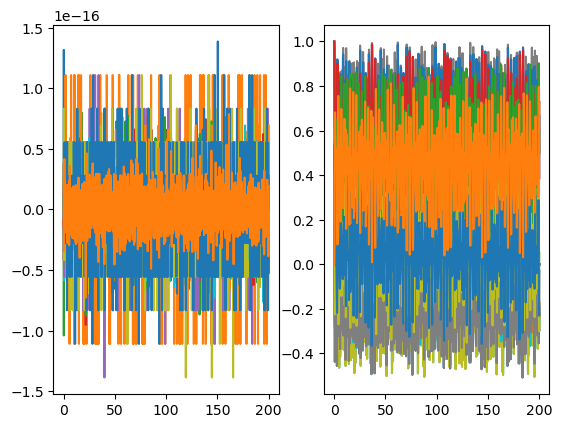

In [20]:
plt.subplot(1,2,1)
plt.plot(time_list,np.imag(Coff_t))
plt.subplot(1,2,2)
plt.plot(time_list,np.real(Coff_t))
plt.show()

In [21]:
index4_0=np.where(np.sum(np.abs(np.real(Coff_t)),axis=0)/1000<1e-5)[0]
Coff_t[:,index4_0]=0

#################   ML part   #################

In [23]:
#######  Define  network and dataset #######
obs_coff=torch.from_numpy(np.real(Coff_t)).float()
time_list_tensor=torch.from_numpy(time_list).float()



In [24]:
Vec_len=obs_coff.shape[1]
func = NNODEF(Vec_len, Vec_len*8, time_invariant=False) #False


ode_trained = NeuralODE(func)


#################################################

In [25]:
# 查看 func的参数总数
total_params = sum(p.numel() for p in func.parameters())

# 输出结果
print(f"Total number of parameters in the model: {total_params}")


Total number of parameters in the model: 1113112


In [26]:
def create_batch():
    delta_t=np.random.uniform(min_delta_time, max_delta_time)
    t0 = np.random.uniform(0, t_max - delta_t)
    t1 = t0 + delta_t
    
    idx = sorted(np.random.permutation(index_np[(times_np > t0) & (times_np < t1)])[:max_points_num])

    obs_ = obs[idx]
    obs_=obs_.unsqueeze(0).repeat(batch_size, 1, 1)
    obs_ += torch.randn_like(obs_) * Noise_strength
    ts_ = times[idx]
    ts_.squeeze()
    return obs_, ts_ 

In [28]:
from itertools import product


# 单量子比特的泡利矩阵
I = np.array([[1, 0], [0, 1]])
X = np.array([[0, 1], [1, 0]])
Y = np.array([[0, -1j], [1j, 0]])
Z = np.array([[1, 0], [0, -1]])

# 构造 n 量子比特的泡利基底
def pauli_basis_xyz(n):
    
    # 基本泡利矩阵的组合
    paulis = [ X, Y, Z]
    basis = []
    for combination in product(paulis, repeat=n):
        # 对每个组合做 Kronecker 积（Kronecker product）
        mat = combination[0]
        for p in combination[1:]:
            mat = np.kron(mat, p)
        basis.append(mat)
    return basis

################evalu_fun###############

In [30]:
def Oper_recon_trunc(n_bas,Coff_n):
    # n_bas=1
    # Coff_n=coff_extract(n_bas,A_t)
    
    i_coff=0
    Operator_n=np.zeros((2**Nq, 2**Nq))
    for num_fro in range(Nq+1-n_bas):
        pauli_basis_matrices = pauli_basis_xyz(n_bas)[0]
        for i_pauli,pauli_mat in enumerate(pauli_basis_xyz(n_bas)) : 
            pauli_mat_complete=pauli_mat
            # print(pauli_mat)
            for i_fro in range(num_fro):
                pauli_mat_complete=np.kron(I,pauli_mat_complete)
            for i_beh in range(Nq-num_fro-n_bas):
                pauli_mat_complete=np.kron(pauli_mat_complete,I)   
            Operator_n=pauli_mat_complete*Coff_n[i_coff]+Operator_n  
            i_coff+=1
    return Operator_n

def Vec_recons_trunc(vec,Nq):
    
    Oper_rec=vec[0] *np.eye(2**Nq)+Oper_recon_trunc(1,vec[1:1+3*Nq])+Oper_recon_trunc(2,vec[1+3*Nq:])

    return Oper_rec

In [31]:
from scipy.interpolate import interp1d
def interpolated_fft(time_list, A_t_psi_rec_list, fs=20, kind='linear', fmax=3):
    """
    对非等间隔采样信号进行插值重采样，并计算其 FFT。

    参数：
    - time_list: 原始时间列表（非等间隔）
    - A_t_psi_rec_list: 原始信号（与 time_list 长度一致）
    - fs: 插值后的采样频率（Hz），默认 20Hz
    - kind: 插值类型（如 'linear' 或 'cubic'）
    - fmax: 返回频率范围的上限（Hz），默认只返回 0 ~ fmax 的频谱

    返回：
    - freqs_half: 频率数组（只包含正频率）
    - fft_amplitudes_half: 幅值数组（对应频率的幅度）
    """

    # 插值函数
    f_inter = interp1d(time_list, np.real(A_t_psi_rec_list), kind=kind)

    # 等间隔时间轴
    t_start, t_end = time_list[0], time_list[-1]
    t_new = np.arange(t_start, t_end, 1/fs)

    # 插值得到新信号
    signal = f_inter(t_new)

    # 计算 FFT
    fft_result = np.fft.fft(signal)
    freqs = np.fft.fftfreq(len(signal), d=1/fs)

    # 只取正频率部分
    half_n = len(signal) // 2
    freqs_half = freqs[:half_n]
    fft_amplitudes_half = np.abs(fft_result[:half_n])

    # 限制最大频率返回
    idx = freqs_half <= fmax
    return freqs_half[idx], fft_amplitudes_half[idx]


fmax=3
f_show_min=0
f_show_max=1.5

def evalu_fun():
    A_t_psi_rec_list=[]
    ini_state_hc=ini_state.conj().T
    # Nq=3
    for i_rec in range(Coff_t.shape[0]):  #
    

        Coff_vec=Coff_t[i_rec]
        Oper_rec=Vec_recons_trunc(Coff_vec,Nq)
        A_t_psi_rec=(ini_state_hc @ Oper_rec @X_sum @ini_state).item()
        A_t_psi_rec_list.append(A_t_psi_rec)
        # if i_rec%100==0:
        #     print(f'evolving step {i_rec}/{Coff_t.shape[0]}')
    plt.subplot(2,1,1)
    plt.plot(time_list[0:N_jump*N_time+1:N_jump],np.real(A_t_psi_rec_list[0:N_jump*N_time+1:N_jump])
             ,label='Trainset')
    plt.plot(time_list[N_jump*N_time+1:],np.real(A_t_psi_rec_list[N_jump*N_time+1:])
             ,label='Testset')
    
    plt.subplot(2,1,2)
    freqs, amps = interpolated_fft(time_list, A_t_psi_rec_list, fs=50, kind='linear', fmax=fmax)
    plt.plot(freqs, amps,label='real', color='blue', linewidth=2)
    freqs, amps = interpolated_fft(time_list[0:N_jump*N_time+1:N_jump], A_t_psi_rec_list_noise[0:N_jump*N_time+1:N_jump], fs=50, kind='linear', fmax=fmax)
    plt.plot(freqs, amps,label='signal',color='black', linewidth=2)
        
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.title("Interpolated FFT Result")
    plt.grid(True)
    
    
    MLp_startpoint_list=range(10,int(N_jump*N_time*1.5),int(N_jump*N_time*2/5))  #[0,50,100,150]
    
    for i_p in enumerate(MLp_startpoint_list):
        MLp_startpoint=MLp_startpoint_list[i_p[0]]
        ini_v=torch.tensor(np.real(Coff_t[MLp_startpoint])).float().unsqueeze(0)     
        t_span=torch.arange(time_list_tensor[MLp_startpoint], time_list[-1], 0.05).unsqueeze(1)
        t_start = time_list_tensor[MLp_startpoint].item()
        
    
        
        ML_result=ode_trained(ini_v, t_span, return_whole_sequence=True)
        ML_result=np.array(ML_result.detach())*1j
        A_t_psi_rec_ML_list=[]
        for i_rec in range(ML_result.shape[0]):
            
               
            ML_vec=ML_result[i_rec].squeeze()
            Oper_rec=Vec_recons_trunc(ML_vec,Nq)
            A_t_psi_rec_ML=(ini_state_hc @ Oper_rec @ X_sum @ini_state).item() #ini_state_hc @ Oper_rec @ini_state
            A_t_psi_rec_ML_list.append(A_t_psi_rec_ML)
            # if i_rec%100==0:
            #     print(f'evolving step {i_rec}/{ML_result.shape[0]}')
        plt.subplot(2,1,1)
        plt.plot(t_span,np.imag(A_t_psi_rec_ML_list),'--',label=f't={t_start:.2f}')
        
        plt.subplot(2,1,2)
        freqs, amps = interpolated_fft(t_span.squeeze().numpy(), A_t_psi_rec_ML_list, fs=50, kind='linear', fmax=fmax)
        plt.plot(freqs, amps,'--',label=f't={t_start:.2f}')
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Amplitude")
        plt.title("Interpolated FFT Result")
   
    plt.subplot(2,1,1)
    # plt.xlim(0,100)
    plt.legend()
    plt.xlabel('t')
    plt.ylabel('<O>(t)')
    # plt.plot(time_list,np.imag(A_t_psi_list),label='RealValue',alpha=0.35)
    # plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))  #图片右侧
    plt.legend(loc='upper right')    
    plt.subplot(2,1,2)
    plt.legend(loc='upper right')
    plt.xlim(f_show_min,f_show_max)
    # plt.yscale('log')
    plt.ylim(0,15000)
    plt.subplots_adjust(hspace=0.5)
    # plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))#图片右侧
    # plt.savefig('FFTresult.pdf')    
    plt.show()
    

In [32]:

# ###test
# evalu_fun()


In [33]:
def moving_average(data, window_size):
    if window_size > len(data):
        return []

    averages = []
    for i in range(len(data) - window_size + 1):
        window = data[i:i + window_size]
        window_avg = sum(window) / window_size
        averages.append(window_avg)
    return averages

# # 示例
# data = [1, 2, 3, 4, 5, 6, 7, 8, 9]
# print(moving_average(data, 3))
# 输出: [2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]


################ Train #################

In [35]:
n_steps=2000  #20000
train_steps=1  #50
plot_freq=10 #100
batch_size=1#64



windowsize=20
min_delta = 2e-3  # 1e-3 # 最小损失下降幅度
patience = 50     # 容忍多少次不显著下降
val_loss_last = float('inf')
counter = 0



z0=obs_coff[0,:]
z0 = Variable(z0)    # Only for keeping the tensor shape
Noise_strength=0.01*0

N_time=50#int(Coff_t.shape[0]/2)#50
N_time_extend=Coff_t.shape[0]-N_time  #Coff_t.shape[0]=200 / 2000
N_jump=4




t_max =time_list_tensor[N_jump*N_time]
n_points = N_time+1

dtime=t_max/N_time



min_delta_time = 10 #dtime*int(N_time*0.35-1)#dtime*5
max_delta_time = dtime*int(N_time*0.35)  #dtime*int(N_time*0.5)
max_points_num = int(N_time/2) #150
times_np=time_list_tensor[0:N_jump*N_time+1:N_jump]
# n_points = N_time
index_np = np.arange(0, N_time+1, 1, dtype=np.int)
obs=obs_coff[0:N_jump*N_time+1:N_jump,:]
times=times_np[:,None]


Nq=5
optimizer = torch.optim.Adam(ode_trained.parameters(), lr=0.0001)  #lr=0.001
start_t = CPUTime.process_time()

/var/folders/ny/j43jfzcd12jf2z_vzp7gqz780000gn/T/ipykernel_57274/3331725889.py:39: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  index_np = np.arange(0, N_time+1, 1, dtype=np.int)


###########show noise ##############

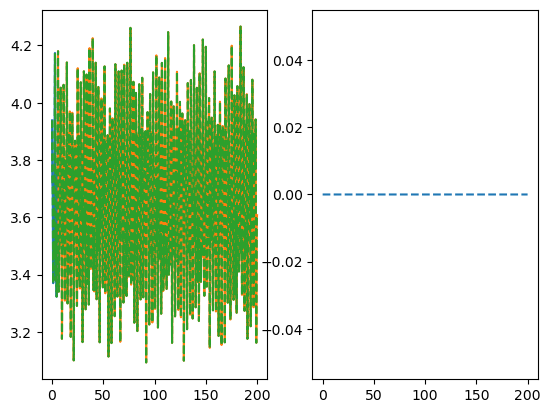

In [37]:
A_t_psi_rec_list=[]
A_t_psi_rec_list_noise=[]
ini_state_hc=ini_state.conj().T
# Nq=3
for i_rec in range(Coff_t.shape[0]):  #

    # Coff_vec=np.array(obs[i_rec,:])*1j
    Coff_vec=Coff_t[i_rec]
    Coff_vec_noise=Coff_vec  +  np.random.normal(loc=0, scale=1, size=Coff_vec.shape)*Noise_strength
    Oper_rec=Vec_recons_trunc(Coff_vec,Nq)
    Oper_rec_noise=Vec_recons_trunc(Coff_vec_noise,Nq)
    A_t_psi_rec=(ini_state_hc @ Oper_rec @ini_state).item()
    A_t_psi_rec_noise=(ini_state_hc @ Oper_rec_noise @ini_state).item()
    A_t_psi_rec_list.append(A_t_psi_rec)
    A_t_psi_rec_list_noise.append(A_t_psi_rec_noise)
    # if i_rec%100==0:
    #     print(f'evolving step {i_rec}/{Coff_t.shape[0]}')
plt.subplot(1,2,1)
plt.plot(time_list[0:N_time+1],np.real(A_t_psi_rec_list[0:N_time+1])
         ,label='Trainset')
plt.plot(time_list[N_time+1:],np.real(A_t_psi_rec_list[N_time+1:])
         ,label='Testset')
plt.plot(time_list,np.real(A_t_psi_rec_list_noise),'--'
         ,label='noiseset')

plt.subplot(1,2,2)
plt.plot(time_list,np.real(A_t_psi_rec_list_noise)-np.real(A_t_psi_rec_list),'--'
         ,label='noiseset')
plt.show()



 pretrain dt=0.4020000100135803  N=50  batchsize=1  Noise_strength=0.0 
loss function : 35.063114166259766  batch_num= 0 当前时间: 2025-06-03 17:38:58


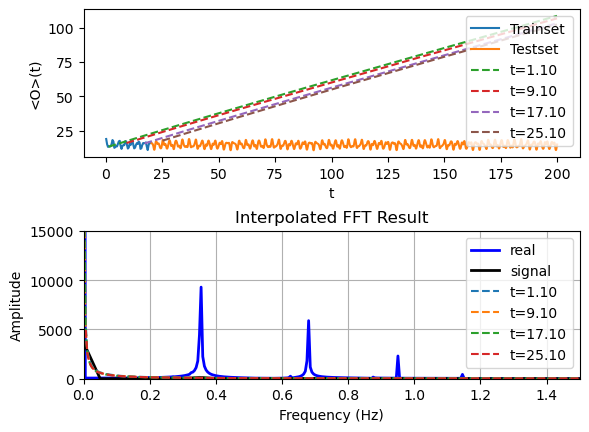

loss function : 16.44173812866211  batch_num= 10 当前时间: 2025-06-03 17:41:58
loss function : 15.633886337280273  batch_num= 20 当前时间: 2025-06-03 17:42:41
loss function : 18.66929817199707  batch_num= 30 当前时间: 2025-06-03 17:43:16
loss function : 24.683027267456055  batch_num= 40 当前时间: 2025-06-03 17:43:50
loss function : 14.324437141418457  batch_num= 50 当前时间: 2025-06-03 17:44:23
loss function : 19.870758056640625  batch_num= 60 当前时间: 2025-06-03 17:44:57
loss function : 28.296323776245117  batch_num= 70 当前时间: 2025-06-03 17:45:29
loss function : 23.167545318603516  batch_num= 80 当前时间: 2025-06-03 17:46:14


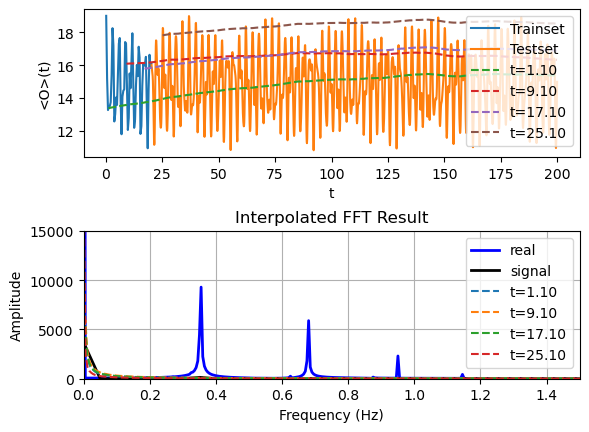

loss function : 16.750131607055664  batch_num= 90 当前时间: 2025-06-03 17:48:39
loss function : 27.973262786865234  batch_num= 100 当前时间: 2025-06-03 17:49:15
loss function : 14.951340675354004  batch_num= 110 当前时间: 2025-06-03 17:49:52
loss function : 15.427783966064453  batch_num= 120 当前时间: 2025-06-03 17:50:27
loss function : 12.64255428314209  batch_num= 130 当前时间: 2025-06-03 17:50:58
loss function : 14.038915634155273  batch_num= 140 当前时间: 2025-06-03 17:51:30
loss function : 21.184398651123047  batch_num= 150 当前时间: 2025-06-03 17:52:03
loss function : 13.909807205200195  batch_num= 160 当前时间: 2025-06-03 17:52:34


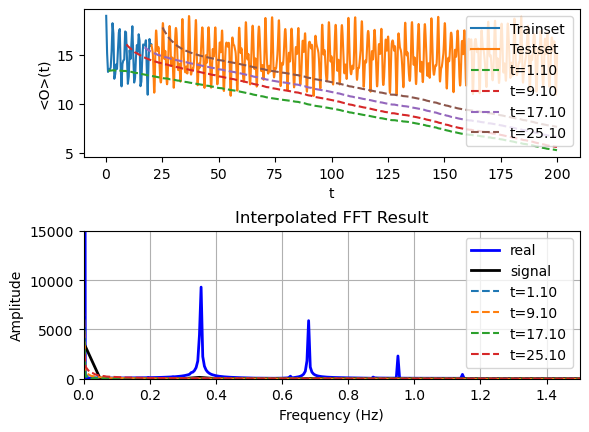

loss function : 13.591917037963867  batch_num= 170 当前时间: 2025-06-03 17:54:48
loss function : 13.431890487670898  batch_num= 180 当前时间: 2025-06-03 17:55:21
loss function : 15.286171913146973  batch_num= 190 当前时间: 2025-06-03 17:55:52
loss function : 13.682687759399414  batch_num= 200 当前时间: 2025-06-03 17:56:26
loss function : 12.718893051147461  batch_num= 210 当前时间: 2025-06-03 17:56:58
loss function : 11.494974136352539  batch_num= 220 当前时间: 2025-06-03 17:57:29
loss function : 12.617815017700195  batch_num= 230 当前时间: 2025-06-03 17:58:03
loss function : 15.840932846069336  batch_num= 240 当前时间: 2025-06-03 17:58:35


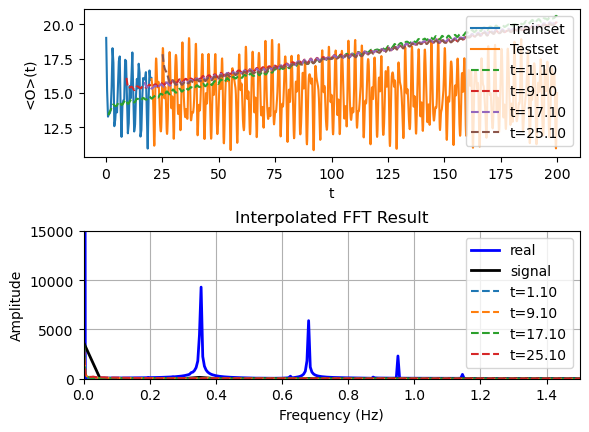

loss function : 12.571175575256348  batch_num= 250 当前时间: 2025-06-03 18:00:51
loss function : 10.352694511413574  batch_num= 260 当前时间: 2025-06-03 18:01:25
loss function : 14.513106346130371  batch_num= 270 当前时间: 2025-06-03 18:01:57
loss function : 12.272032737731934  batch_num= 280 当前时间: 2025-06-03 18:02:29
loss function : 14.341828346252441  batch_num= 290 当前时间: 2025-06-03 18:03:02
loss function : 12.34361457824707  batch_num= 300 当前时间: 2025-06-03 18:03:36
loss function : 9.90240478515625  batch_num= 310 当前时间: 2025-06-03 18:04:08
loss function : 10.457301139831543  batch_num= 320 当前时间: 2025-06-03 18:04:42


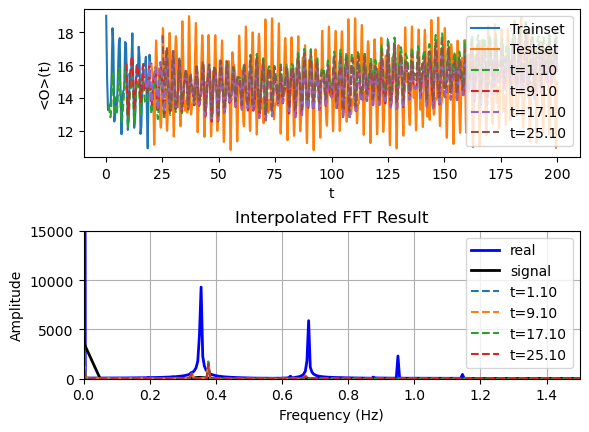

loss function : 9.570737838745117  batch_num= 330 当前时间: 2025-06-03 18:06:54
loss function : 7.675081253051758  batch_num= 340 当前时间: 2025-06-03 18:07:25
loss function : 9.615736961364746  batch_num= 350 当前时间: 2025-06-03 18:08:00
loss function : 6.021667957305908  batch_num= 360 当前时间: 2025-06-03 18:08:31
loss function : 4.957908630371094  batch_num= 370 当前时间: 2025-06-03 18:09:05
loss function : 6.669826507568359  batch_num= 380 当前时间: 2025-06-03 18:09:38
loss function : 8.51097583770752  batch_num= 390 当前时间: 2025-06-03 18:10:12
loss function : 7.7028937339782715  batch_num= 400 当前时间: 2025-06-03 18:10:45


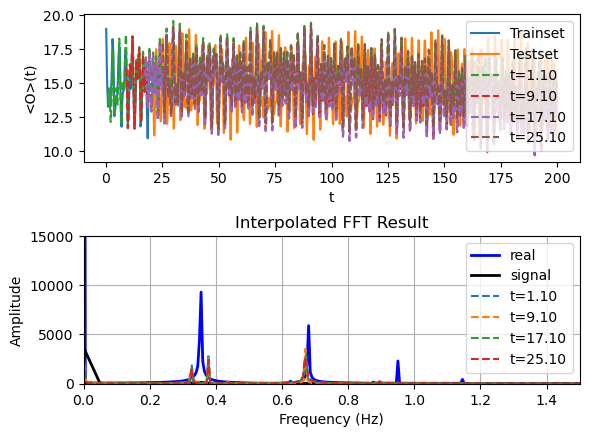

loss function : 8.8355131149292  batch_num= 410 当前时间: 2025-06-03 18:12:59
loss function : 5.905608654022217  batch_num= 420 当前时间: 2025-06-03 18:13:31
loss function : 5.688312530517578  batch_num= 430 当前时间: 2025-06-03 18:14:09
loss function : 5.500531196594238  batch_num= 440 当前时间: 2025-06-03 18:14:43
loss function : 6.454171657562256  batch_num= 450 当前时间: 2025-06-03 18:15:16
loss function : 6.207499980926514  batch_num= 460 当前时间: 2025-06-03 18:15:56
loss function : 6.063277721405029  batch_num= 470 当前时间: 2025-06-03 18:16:42
loss function : 5.446852207183838  batch_num= 480 当前时间: 2025-06-03 18:17:25


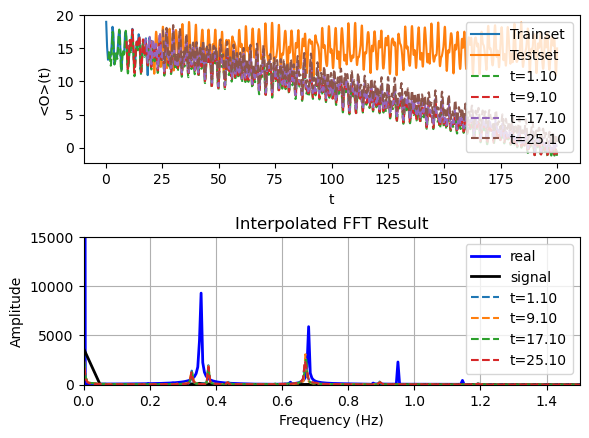

loss function : 5.907445907592773  batch_num= 490 当前时间: 2025-06-03 18:19:59
loss function : 5.8592939376831055  batch_num= 500 当前时间: 2025-06-03 18:20:29
loss function : 5.360424995422363  batch_num= 510 当前时间: 2025-06-03 18:21:00
loss function : 4.621662616729736  batch_num= 520 当前时间: 2025-06-03 18:21:34
loss function : 8.470683097839355  batch_num= 530 当前时间: 2025-06-03 18:22:07
loss function : 5.301385879516602  batch_num= 540 当前时间: 2025-06-03 18:22:40
loss function : 5.7263407707214355  batch_num= 550 当前时间: 2025-06-03 18:23:15
loss function : 5.138925552368164  batch_num= 560 当前时间: 2025-06-03 18:23:52


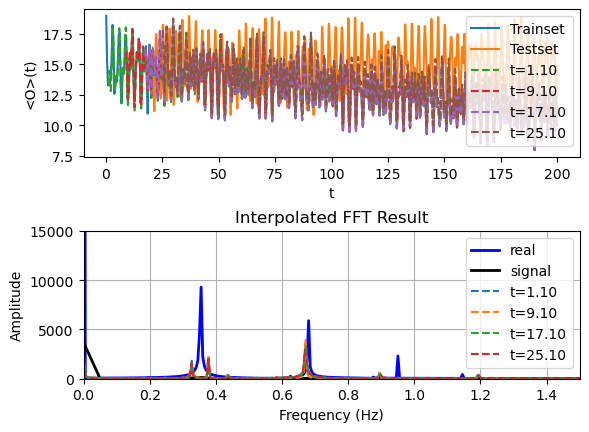

loss function : 4.367013931274414  batch_num= 570 当前时间: 2025-06-03 18:26:13
loss function : 6.559689044952393  batch_num= 580 当前时间: 2025-06-03 18:26:44
loss function : 4.8136067390441895  batch_num= 590 当前时间: 2025-06-03 18:27:17
loss function : 5.320314407348633  batch_num= 600 当前时间: 2025-06-03 18:27:49
loss function : 3.8976268768310547  batch_num= 610 当前时间: 2025-06-03 18:28:22
loss function : 4.76522970199585  batch_num= 620 当前时间: 2025-06-03 18:28:55
loss function : 4.613859176635742  batch_num= 630 当前时间: 2025-06-03 18:29:28
loss function : 2.534965753555298  batch_num= 640 当前时间: 2025-06-03 18:30:01


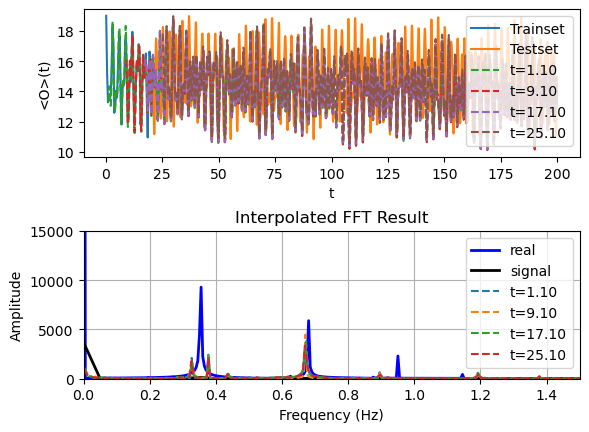

loss function : 2.874969959259033  batch_num= 650 当前时间: 2025-06-03 18:32:12
loss function : 3.8486127853393555  batch_num= 660 当前时间: 2025-06-03 18:32:44
loss function : 5.061938285827637  batch_num= 670 当前时间: 2025-06-03 18:33:16
loss function : 2.8184423446655273  batch_num= 680 当前时间: 2025-06-03 18:33:48
loss function : 2.5339696407318115  batch_num= 690 当前时间: 2025-06-03 18:34:21
loss function : 2.7027266025543213  batch_num= 700 当前时间: 2025-06-03 18:34:54
loss function : 2.9605793952941895  batch_num= 710 当前时间: 2025-06-03 18:35:26
loss function : 2.143812417984009  batch_num= 720 当前时间: 2025-06-03 18:35:57


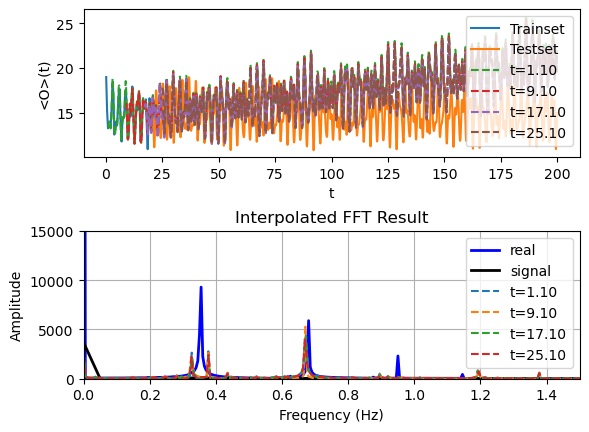

loss function : 3.39361572265625  batch_num= 730 当前时间: 2025-06-03 18:38:24
loss function : 2.183570623397827  batch_num= 740 当前时间: 2025-06-03 18:38:55
loss function : 3.648426055908203  batch_num= 750 当前时间: 2025-06-03 18:39:30
loss function : 4.027544021606445  batch_num= 760 当前时间: 2025-06-03 18:40:02
loss function : 3.665245771408081  batch_num= 770 当前时间: 2025-06-03 18:40:33
loss function : 2.5913898944854736  batch_num= 780 当前时间: 2025-06-03 18:41:06
loss function : 2.897146224975586  batch_num= 790 当前时间: 2025-06-03 18:41:39
loss function : 2.269716501235962  batch_num= 800 当前时间: 2025-06-03 18:42:11


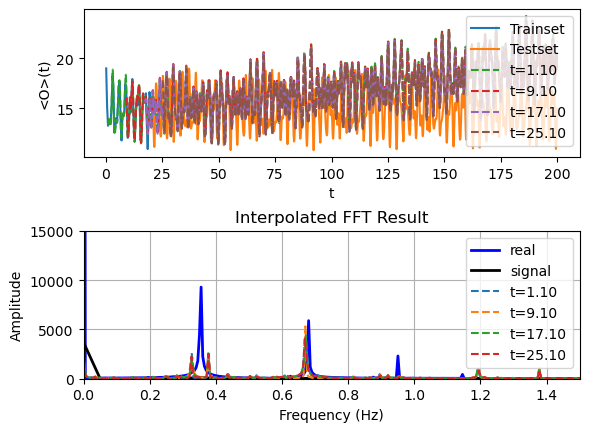

loss function : 2.359842300415039  batch_num= 810 当前时间: 2025-06-03 18:44:28
loss function : 3.150336742401123  batch_num= 820 当前时间: 2025-06-03 18:45:01
loss function : 3.5060365200042725  batch_num= 830 当前时间: 2025-06-03 18:45:36
loss function : 4.114788055419922  batch_num= 840 当前时间: 2025-06-03 18:46:10
loss function : 3.477278232574463  batch_num= 850 当前时间: 2025-06-03 18:46:42
loss function : 1.739084005355835  batch_num= 860 当前时间: 2025-06-03 18:47:12
loss function : 1.8489609956741333  batch_num= 870 当前时间: 2025-06-03 18:47:45
loss function : 2.5268821716308594  batch_num= 880 当前时间: 2025-06-03 18:48:17


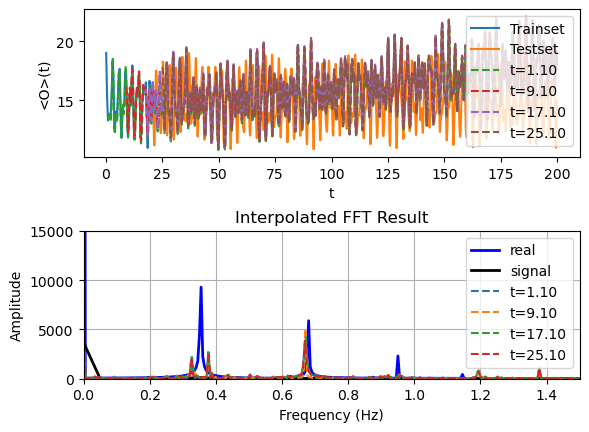

loss function : 2.721632480621338  batch_num= 890 当前时间: 2025-06-03 18:50:32
loss function : 3.039841890335083  batch_num= 900 当前时间: 2025-06-03 18:51:06
loss function : 1.6885206699371338  batch_num= 910 当前时间: 2025-06-03 18:51:38
loss function : 2.700575828552246  batch_num= 920 当前时间: 2025-06-03 18:52:12
loss function : 1.9991649389266968  batch_num= 930 当前时间: 2025-06-03 18:52:45
loss function : 2.18444561958313  batch_num= 940 当前时间: 2025-06-03 18:53:21
loss function : 2.401447296142578  batch_num= 950 当前时间: 2025-06-03 18:53:53
loss function : 1.7593919038772583  batch_num= 960 当前时间: 2025-06-03 18:54:27


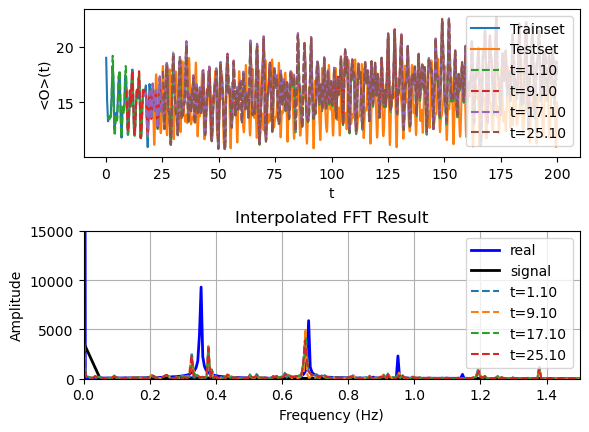

loss function : 1.3978345394134521  batch_num= 970 当前时间: 2025-06-03 18:56:45
loss function : 2.1331968307495117  batch_num= 980 当前时间: 2025-06-03 18:57:23
loss function : 2.8843417167663574  batch_num= 990 当前时间: 2025-06-03 18:57:57
loss function : 2.538581132888794  batch_num= 1000 当前时间: 2025-06-03 18:58:32
loss function : 1.3491878509521484  batch_num= 1010 当前时间: 2025-06-03 18:59:04
loss function : 2.4200406074523926  batch_num= 1020 当前时间: 2025-06-03 18:59:37
loss function : 1.063947319984436  batch_num= 1030 当前时间: 2025-06-03 19:00:14
loss function : 1.4003064632415771  batch_num= 1040 当前时间: 2025-06-03 19:00:50


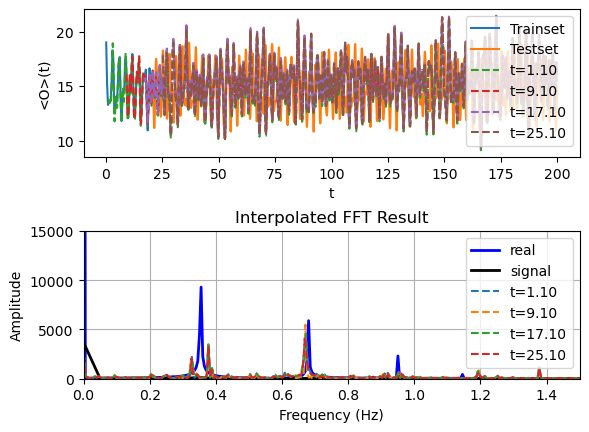

loss function : 1.3488976955413818  batch_num= 1050 当前时间: 2025-06-03 19:03:08
loss function : 1.430413007736206  batch_num= 1060 当前时间: 2025-06-03 19:03:44
loss function : 1.9185316562652588  batch_num= 1070 当前时间: 2025-06-03 19:04:20
loss function : 2.0520641803741455  batch_num= 1080 当前时间: 2025-06-03 19:04:57
loss function : 3.023355484008789  batch_num= 1090 当前时间: 2025-06-03 19:05:33
loss function : 2.477142095565796  batch_num= 1100 当前时间: 2025-06-03 19:06:15
loss function : 1.2226901054382324  batch_num= 1110 当前时间: 2025-06-03 19:06:49
loss function : 1.9303503036499023  batch_num= 1120 当前时间: 2025-06-03 19:07:22


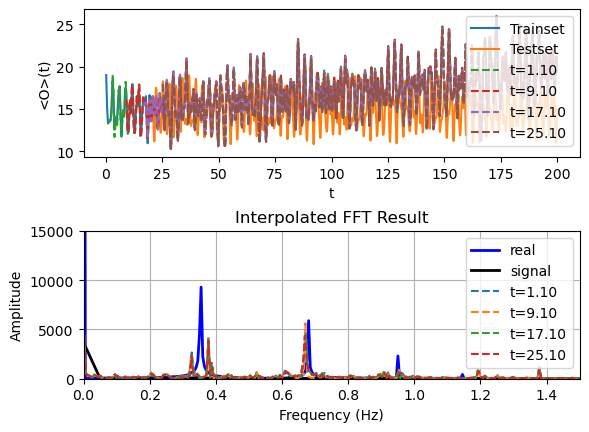

loss function : 1.378383994102478  batch_num= 1130 当前时间: 2025-06-03 19:09:40
loss function : 2.1062560081481934  batch_num= 1140 当前时间: 2025-06-03 19:10:16
loss function : 1.8991551399230957  batch_num= 1150 当前时间: 2025-06-03 19:10:54
loss function : 0.9555268287658691  batch_num= 1160 当前时间: 2025-06-03 19:11:27
loss function : 1.7780447006225586  batch_num= 1170 当前时间: 2025-06-03 19:12:05
loss function : 1.2223106622695923  batch_num= 1180 当前时间: 2025-06-03 19:12:38
loss function : 2.4861512184143066  batch_num= 1190 当前时间: 2025-06-03 19:13:10
loss function : 1.2320873737335205  batch_num= 1200 当前时间: 2025-06-03 19:13:44


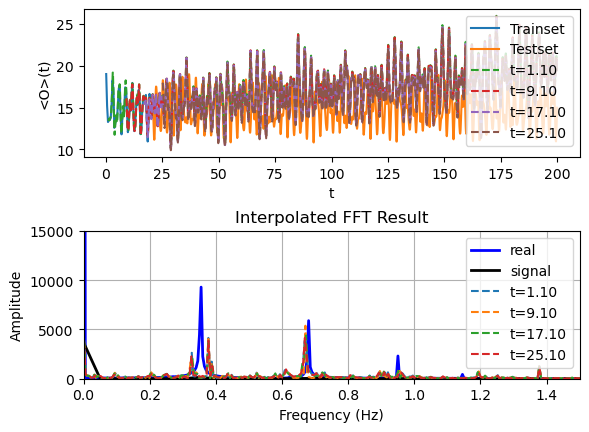

loss function : 0.7448628544807434  batch_num= 1210 当前时间: 2025-06-03 19:16:00
loss function : 1.2473704814910889  batch_num= 1220 当前时间: 2025-06-03 19:16:47
loss function : 0.7649141550064087  batch_num= 1230 当前时间: 2025-06-03 19:17:52
loss function : 0.9632675051689148  batch_num= 1240 当前时间: 2025-06-03 19:18:44
loss function : 1.4742231369018555  batch_num= 1250 当前时间: 2025-06-03 19:19:31
loss function : 0.6927546858787537  batch_num= 1260 当前时间: 2025-06-03 19:20:20
loss function : 0.8981454968452454  batch_num= 1270 当前时间: 2025-06-03 19:20:57
loss function : 2.3840839862823486  batch_num= 1280 当前时间: 2025-06-03 19:21:32


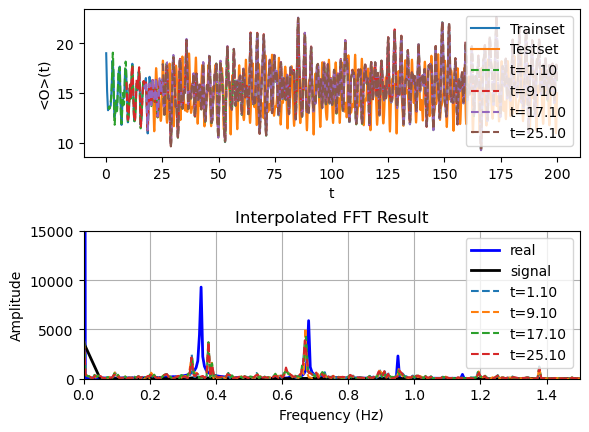

loss function : 1.8531051874160767  batch_num= 1290 当前时间: 2025-06-03 19:23:50
loss function : 1.2985045909881592  batch_num= 1300 当前时间: 2025-06-03 19:24:25
loss function : 0.7769528031349182  batch_num= 1310 当前时间: 2025-06-03 19:25:02
loss function : 1.0744333267211914  batch_num= 1320 当前时间: 2025-06-03 19:25:37
loss function : 0.5030470490455627  batch_num= 1330 当前时间: 2025-06-03 19:26:14
loss function : 1.452422022819519  batch_num= 1340 当前时间: 2025-06-03 19:26:51
loss function : 0.683383584022522  batch_num= 1350 当前时间: 2025-06-03 19:27:28
loss function : 0.706737220287323  batch_num= 1360 当前时间: 2025-06-03 19:28:05


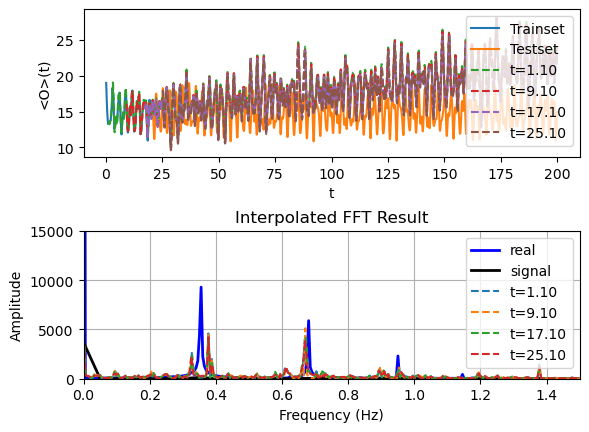

loss function : 0.7224205136299133  batch_num= 1370 当前时间: 2025-06-03 19:30:33
loss function : 1.0279172658920288  batch_num= 1380 当前时间: 2025-06-03 19:31:07
loss function : 0.9180252552032471  batch_num= 1390 当前时间: 2025-06-03 19:31:41
loss function : 0.6137160658836365  batch_num= 1400 当前时间: 2025-06-03 19:32:16
loss function : 0.9843262434005737  batch_num= 1410 当前时间: 2025-06-03 19:32:50
loss function : 0.7626915574073792  batch_num= 1420 当前时间: 2025-06-03 19:33:22
loss function : 0.5841110944747925  batch_num= 1430 当前时间: 2025-06-03 19:33:58
loss function : 0.5344412326812744  batch_num= 1440 当前时间: 2025-06-03 19:34:31


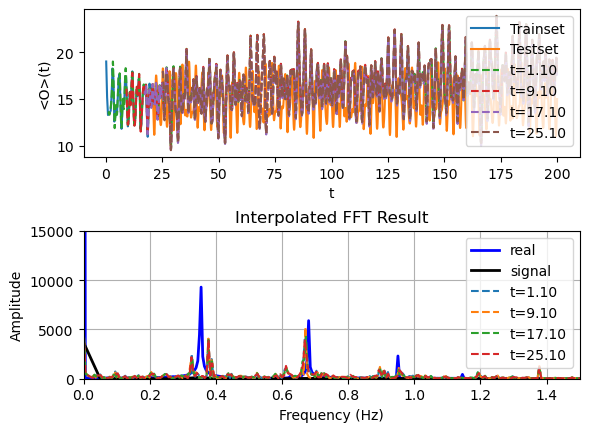

loss function : 0.6163186430931091  batch_num= 1450 当前时间: 2025-06-03 19:36:45
loss function : 0.946997880935669  batch_num= 1460 当前时间: 2025-06-03 19:37:17
loss function : 1.5344839096069336  batch_num= 1470 当前时间: 2025-06-03 19:37:51
loss function : 1.5745912790298462  batch_num= 1480 当前时间: 2025-06-03 19:38:25
loss function : 0.8908059000968933  batch_num= 1490 当前时间: 2025-06-03 19:39:00
loss function : 0.6546393036842346  batch_num= 1500 当前时间: 2025-06-03 19:39:36
loss function : 0.7216532230377197  batch_num= 1510 当前时间: 2025-06-03 19:40:12
loss function : 0.9368724822998047  batch_num= 1520 当前时间: 2025-06-03 19:40:46


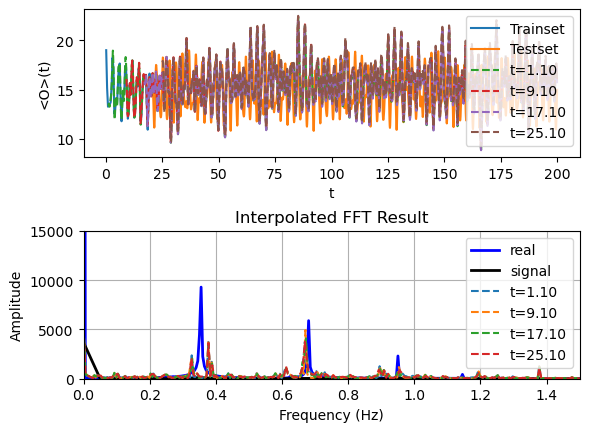

loss function : 0.8360756039619446  batch_num= 1530 当前时间: 2025-06-03 19:43:01
loss function : 0.41878145933151245  batch_num= 1540 当前时间: 2025-06-03 19:43:35
loss function : 0.8127161860466003  batch_num= 1550 当前时间: 2025-06-03 19:44:07
loss function : 0.7833086848258972  batch_num= 1560 当前时间: 2025-06-03 19:44:42
loss function : 0.5129285454750061  batch_num= 1570 当前时间: 2025-06-03 19:45:15
loss function : 0.7114980816841125  batch_num= 1580 当前时间: 2025-06-03 19:45:50
loss function : 0.7304999232292175  batch_num= 1590 当前时间: 2025-06-03 19:46:23
loss function : 0.5935279726982117  batch_num= 1600 当前时间: 2025-06-03 19:46:56


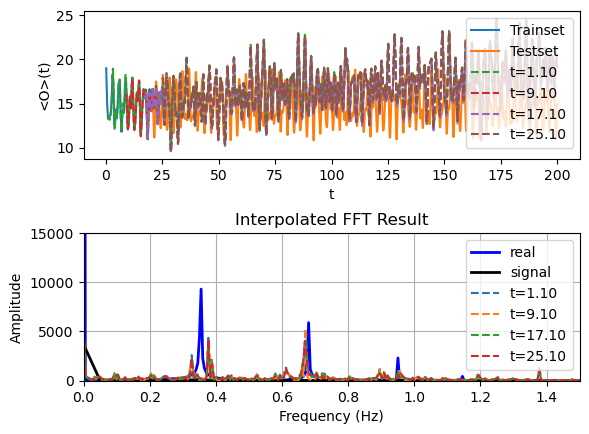

loss function : 0.615715503692627  batch_num= 1610 当前时间: 2025-06-03 19:49:10
loss function : 0.25472089648246765  batch_num= 1620 当前时间: 2025-06-03 19:49:46
loss function : 0.33179453015327454  batch_num= 1630 当前时间: 2025-06-03 19:50:21
loss function : 0.37182700634002686  batch_num= 1640 当前时间: 2025-06-03 19:50:54
loss function : 0.19724257290363312  batch_num= 1650 当前时间: 2025-06-03 19:51:26
loss function : 0.4919080436229706  batch_num= 1660 当前时间: 2025-06-03 19:51:58
loss function : 0.26938119530677795  batch_num= 1670 当前时间: 2025-06-03 19:52:57
loss function : 0.3775423467159271  batch_num= 1680 当前时间: 2025-06-03 19:53:30


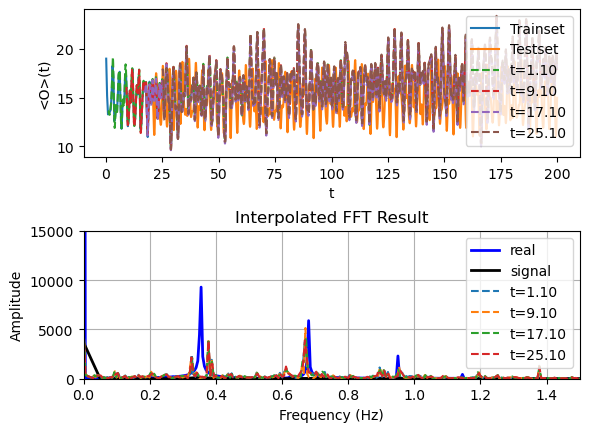

loss function : 0.5787755846977234  batch_num= 1690 当前时间: 2025-06-03 20:11:26
loss function : 1.0035686492919922  batch_num= 1700 当前时间: 2025-06-03 20:11:56
loss function : 0.24880710244178772  batch_num= 1710 当前时间: 2025-06-03 20:12:27
loss function : 0.2660045623779297  batch_num= 1720 当前时间: 2025-06-03 20:12:55
loss function : 0.2971821129322052  batch_num= 1730 当前时间: 2025-06-03 20:13:29
loss function : 0.2727351486682892  batch_num= 1740 当前时间: 2025-06-03 20:14:00
loss function : 0.3308623433113098  batch_num= 1750 当前时间: 2025-06-03 20:14:29
loss function : 0.25727370381355286  batch_num= 1760 当前时间: 2025-06-03 20:14:57


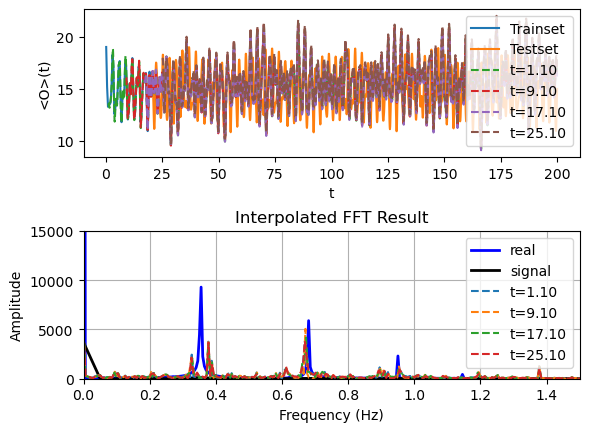

loss function : 0.320957750082016  batch_num= 1770 当前时间: 2025-06-03 20:16:59
loss function : 0.520967960357666  batch_num= 1780 当前时间: 2025-06-03 20:17:33
loss function : 0.2435580939054489  batch_num= 1790 当前时间: 2025-06-03 20:18:12
loss function : 0.13411548733711243  batch_num= 1800 当前时间: 2025-06-03 20:18:48
loss function : 0.1768038123846054  batch_num= 1810 当前时间: 2025-06-03 20:19:25
loss function : 0.3761531412601471  batch_num= 1820 当前时间: 2025-06-03 20:19:57
loss function : 0.2124006450176239  batch_num= 1830 当前时间: 2025-06-03 20:20:27
loss function : 0.1501457542181015  batch_num= 1840 当前时间: 2025-06-03 20:20:58


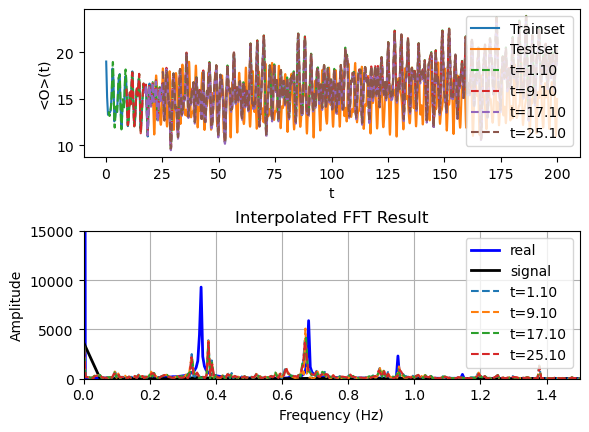

loss function : 0.17698046565055847  batch_num= 1850 当前时间: 2025-06-03 20:22:57
loss function : 0.20563429594039917  batch_num= 1860 当前时间: 2025-06-03 20:23:23
loss function : 0.1616968959569931  batch_num= 1870 当前时间: 2025-06-03 20:23:48
loss function : 0.275279700756073  batch_num= 1880 当前时间: 2025-06-03 20:24:15
loss function : 0.3003438711166382  batch_num= 1890 当前时间: 2025-06-03 20:24:43
loss function : 0.8225604295730591  batch_num= 1900 当前时间: 2025-06-03 20:25:12
loss function : 0.18157605826854706  batch_num= 1910 当前时间: 2025-06-03 20:25:41
loss function : 0.3463260531425476  batch_num= 1920 当前时间: 2025-06-03 20:26:09


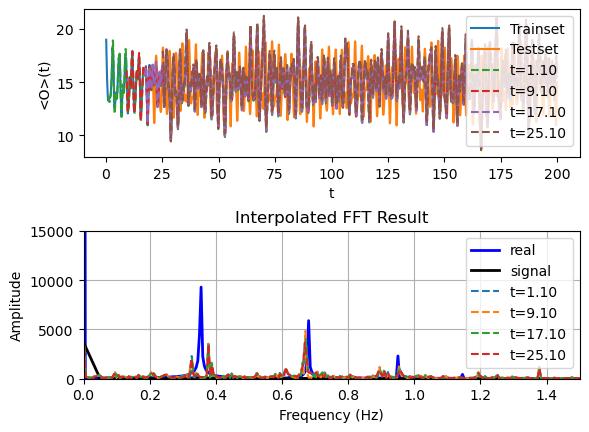

loss function : 0.41784074902534485  batch_num= 1930 当前时间: 2025-06-03 20:28:11
loss function : 0.30664321780204773  batch_num= 1940 当前时间: 2025-06-03 20:28:44
loss function : 0.45744696259498596  batch_num= 1950 当前时间: 2025-06-03 20:29:19
loss function : 0.11378934979438782  batch_num= 1960 当前时间: 2025-06-03 20:29:52
loss function : 0.3960408866405487  batch_num= 1970 当前时间: 2025-06-03 20:30:22
loss function : 0.1799728125333786  batch_num= 1980 当前时间: 2025-06-03 20:30:53
loss function : 0.2390943169593811  batch_num= 1990 当前时间: 2025-06-03 20:31:25


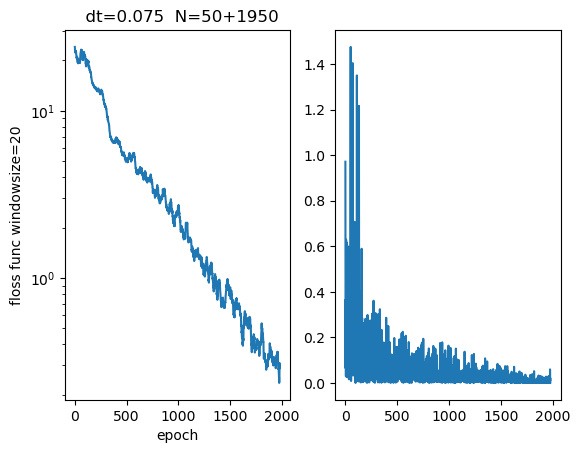

CPU time : 54908.823845 s


In [38]:
# # Train Neural ODE


print(f" pretrain dt={dtime}  N={N_time}  batchsize={batch_size}  Noise_strength={Noise_strength} " )
loss_list=[]
for i in range(n_steps):
    obs_, ts_ = create_batch()
    # obs_=obs_list[i]
    # ts_=ts_list[i]
    
    z_ = ode_trained(obs_[:,0], ts_.squeeze(), return_whole_sequence=True)
    # loss = F.mse_loss(z_, obs_.detach())
    
    z_=z_.transpose(0, 1)
    loss1=F.mse_loss(z_, obs_.detach())
    loss1=2*loss1/(z_.shape[0]+1)*10**3#/batch_size
    
    loss=loss1
    
    loss_list.append(loss.detach().numpy())
    optimizer.zero_grad()
    loss.backward(retain_graph=True)
    optimizer.step()
    if i % plot_freq == 0:
        # 获取当前时间的结构化表示
        local_time = time.localtime()
        # 使用strftime格式化输出时间
        formatted_time = time.strftime("%Y-%m-%d %H:%M:%S", local_time)
        # print("", )
        print(f"loss function : {to_np(loss)}  batch_num= {i} 当前时间: {formatted_time}" )
        
    if i % (8*plot_freq) == 0:
        
        evalu_fun()    
############### early stopping ################

    val_loss=moving_average(loss_list[-windowsize:],windowsize)
    val_loss=np.array(val_loss)
    if i < windowsize:
        continue
    else:
        if val_loss_last - val_loss > min_delta:
            
            counter = 0  # 有明显进步，重置计数器
        else:
            counter += 1  # 没明显进步，计数器加1
    
        if counter >= patience:
            print(f"Early stopping at epoch {i}")
            break
    val_loss_last = val_loss        
    # print(counter)




###########################################################
        
# # Plot result
# figure = plt.figure(figsize=(12, 16))

Ave_loss=np.array(moving_average(loss_list,windowsize))
plt.subplot(1,2,1)
plt.plot(Ave_loss)

plt.yscale('log')
plt.xlabel("epoch")
plt.ylabel(f"floss func windowsize={windowsize}")
plt.title(f"  dt={0.075}  N={N_time}+{N_time_extend}")

plt.subplot(1,2,2)
plt.plot(np.abs(np.diff(Ave_loss)))

plt.show()
end_t = CPUTime.process_time()
print(f"CPU time : {end_t - start_t} s")

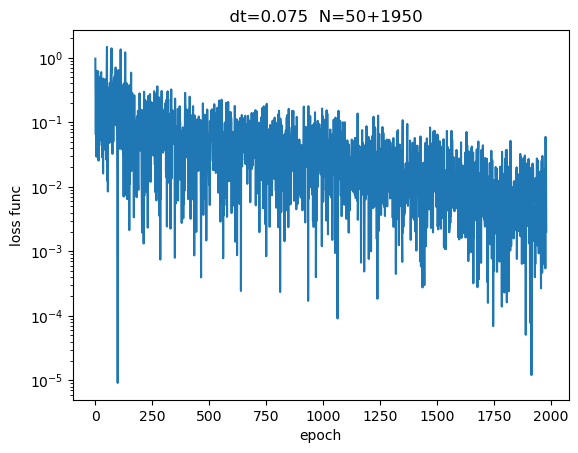

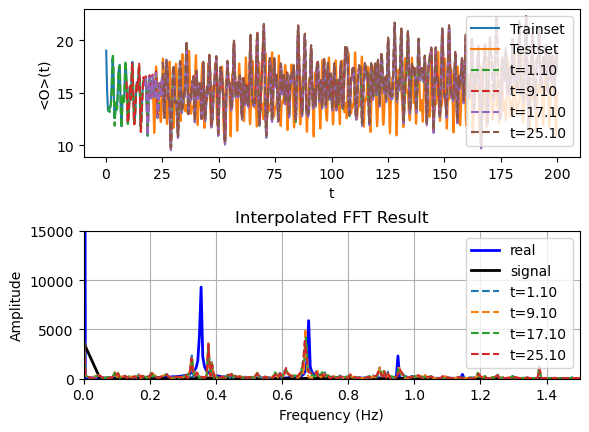

In [42]:
Ave_loss=np.array(moving_average(loss_list,windowsize))
plt.plot(np.abs(np.diff(Ave_loss)))
# plt.plot(loss_list)
plt.yscale('log')
plt.xlabel("epoch")
plt.ylabel("loss func")
plt.title(f"  dt={0.075}  N={N_time}+{N_time_extend}")
plt.show()
evalu_fun()



In [43]:
torch.save(ode_trained, "model_trunc_earlystop.pth")  # 保存完整模型

################load instead of training###############

In [45]:
# ode_trained=torch.load("model_2layers01.pth")

#######################coeffi##############################

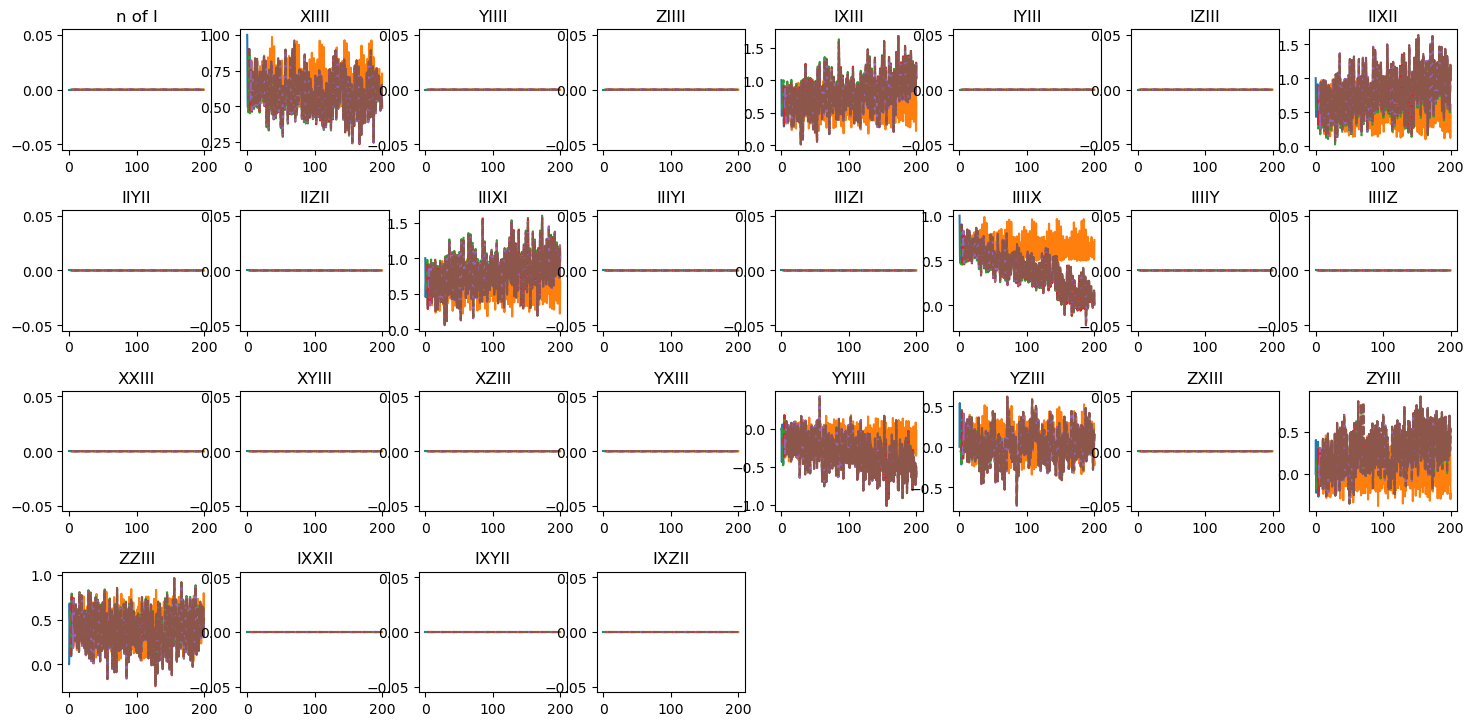

In [47]:
MLp_startpoint_list=range(10,int(N_time*1.5),20)  #[0,50,100,150]
plt.figure(figsize=(18, 18))
for ishow in range(28):
    plt.subplot(8,8,ishow+1)
    plt.plot(time_list[0:N_time+1],np.real(Coff_t[0:N_time+1,ishow]))
    plt.plot(time_list[N_time+1:],np.real(Coff_t[N_time+1:,ishow]))
    plt.title(name_trunc[ishow])
# plt.savefig("coff_t_full_with_noise_dataonly.png", dpi=300)
for i_p in enumerate(MLp_startpoint_list):
    MLp_startpoint=MLp_startpoint_list[i_p[0]]
    ini_v=torch.tensor(np.real(Coff_t[MLp_startpoint])).float().unsqueeze(0)
    # t_span=time_list_tensor[MLp_startpoint:,None].float()
    t_span=torch.arange(time_list_tensor[MLp_startpoint], time_list[-1], 0.05).unsqueeze(1)
    t_start = time_list_tensor[MLp_startpoint].item()
    # t_span=t_span[0]+(t_span-t_span[0])*2    
    ML_result=ode_trained(ini_v, t_span, return_whole_sequence=True)
    ML_result=np.array(ML_result.detach()).squeeze()
    for ishow in range(28):
        plt.subplot(8,8,ishow+1)
        plt.plot(t_span,np.real(ML_result[:,ishow]),'--')

    # ML_result.squeeze().shape
# plt.savefig("coff_t_full_with_noise.png", dpi=300)
plt.subplots_adjust(hspace=0.5) 
plt.show()

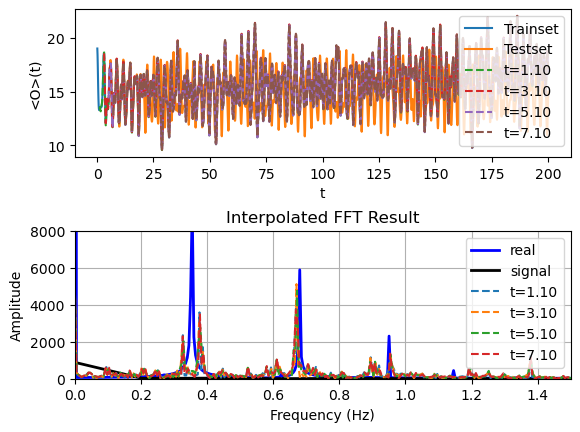

In [147]:
A_t_psi_rec_list=[]
ini_state_hc=ini_state.conj().T
# Nq=3
for i_rec in range(Coff_t.shape[0]):  #

    # Coff_vec=np.array(obs[i_rec,:])*1j
    Coff_vec=Coff_t[i_rec]
    Oper_rec=Vec_recons_trunc(Coff_vec,Nq)
    A_t_psi_rec=(ini_state_hc @ Oper_rec@ X_sum @ini_state).item()
    A_t_psi_rec_list.append(A_t_psi_rec)
    # if i_rec%100==0:
    #     print(f'evolving step {i_rec}/{Coff_t.shape[0]}')
plt.subplot(2,1,1)
plt.plot(time_list[0:N_time+1],np.real(A_t_psi_rec_list[0:N_time+1])
         ,label='Trainset')
plt.plot(time_list[N_time+1:],np.real(A_t_psi_rec_list[N_time+1:])
         ,label='Testset')

plt.subplot(2,1,2)
freqs, amps = interpolated_fft(time_list, A_t_psi_rec_list, fs=50, kind='linear', fmax=fmax)
plt.plot(freqs, amps,label='real', color='blue', linewidth=2)
freqs, amps = interpolated_fft(time_list[0:N_time], A_t_psi_rec_list_noise[0:N_time], fs=50, kind='linear', fmax=fmax)
plt.plot(freqs, amps,label='signal',color='black', linewidth=2)
    
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Interpolated FFT Result")
plt.grid(True)


MLp_startpoint_list=range(10,int(N_time*1.5),int(N_time*2/5))  #[0,50,100,150]

for i_p in enumerate(MLp_startpoint_list):
    MLp_startpoint=MLp_startpoint_list[i_p[0]]
    ini_v=torch.tensor(np.real(Coff_t[MLp_startpoint])).float().unsqueeze(0)
    # t_span=time_list_tensor[MLp_startpoint:,None].float()
    t_span=torch.arange(time_list_tensor[MLp_startpoint], time_list[-1], 0.05).unsqueeze(1)
    t_start = time_list_tensor[MLp_startpoint].item()
    # t_span=t_span[0]+(t_span-t_span[0])*2

    
    ML_result=ode_trained(ini_v, t_span, return_whole_sequence=True)
    ML_result=np.array(ML_result.detach())*1j
    A_t_psi_rec_ML_list=[]
    for i_rec in range(ML_result.shape[0]):
        
            # Coff_vec=np.array(obs[i_rec,:])*1j
        ML_vec=ML_result[i_rec].squeeze()
        Oper_rec=Vec_recons_trunc(ML_vec,Nq)
        A_t_psi_rec_ML=(ini_state_hc @ Oper_rec @ X_sum @ini_state).item()
        A_t_psi_rec_ML_list.append(A_t_psi_rec_ML)
        # if i_rec%100==0:
        #     print(f'evolving step {i_rec}/{ML_result.shape[0]}')
    plt.subplot(2,1,1)
    plt.plot(t_span,np.imag(A_t_psi_rec_ML_list),'--',label=f't={t_start:.2f}')
    
    plt.subplot(2,1,2)
    freqs, amps = interpolated_fft(t_span.squeeze().numpy(), A_t_psi_rec_ML_list, fs=50, kind='linear', fmax=fmax)
    plt.plot(freqs, amps,'--',label=f't={t_start:.2f}')
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.title("Interpolated FFT Result")

plt.subplot(2,1,1)
plt.legend()
plt.xlabel('t')
plt.ylabel('<O>(t)')
# plt.plot(time_list,np.imag(A_t_psi_list),label='RealValue',alpha=0.35)
# plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))  #图片右侧
plt.legend(loc='upper right')
# plt.xlim(0,100)
plt.subplot(2,1,2)
plt.legend(loc='upper right')
plt.xlim(f_show_min,f_show_max)
# plt.yscale('log')
plt.ylim(0,8000)
plt.subplots_adjust(hspace=0.5)
# plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))#图片右侧
from datetime import datetime

# 生成时间戳
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"FFTresult_{timestamp}.pdf"
plt.savefig(filename)    
plt.show()